---Mangesh S Rajguru From TE 39---


Experiment 5 : Data Analytics II<br>
DataSet      : Create Own Dataset<br>
Objective    : To yes or no for Purchase the Product

In [41]:
# Explaination And Illustration :
# In this Experiment We created our own dataset
# then define feature and target,perform 80% training and 20% testing , then train the model, followed by making predictions and
# evaluating the model and  finally creating the heatmap for the confusion Matrix

In [30]:
# Steps :1) Import Libraries 
#        2) craete your own dataset
#        3) Define Features and Target 
#           Where we put features on the X axis and target on the Y axis as price
#        4) Split into train and test
#           Where we train the model 80% and test it on 20%
#        5) Train the model
#           Here, we provide the dataset to the empty model and start the training
#        6) Make Predictions
#           Here, we gave the model x values and got y values
#        7) find the confudion matrix
#           where TP,TN,FP,FN means
#        8) Plot Actual Vs Predicted

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [32]:
# Step 1: Create Dataset (Social Network Ads)
# We create similar data since file may not be available
np.random.seed(42)
n = 400

age = np.random.randint(18, 60, n)
salary = np.random.randint(15000, 150000, n)
# People who are older AND have higher salary tend to buy
purchased = ((age > 35) & (salary > 70000)).astype(int)
# Add some noise
noise = np.random.randint(0, 2, n)
purchased = np.where(np.random.rand(n) > 0.85, noise, purchased)

df = pd.DataFrame({
    'Age': age,
    'EstimatedSalary': salary,
    'Purchased': purchased
})

print("Dataset Created!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print(f"\nClass Distribution:\n{df['Purchased'].value_counts()}")

Dataset Created!
Shape: (400, 3)

First 5 rows:
   Age  EstimatedSalary  Purchased
0   56            20237          0
1   46            35056          0
2   32           129548          0
3   25           126488          0
4   38           149415          1

Class Distribution:
Purchased
0    252
1    148
Name: count, dtype: int64


In [33]:
# Step 2: Define Features and Target
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

In [34]:
# Step 3: Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")


Training samples: 320
Testing samples: 80


In [35]:
# Step 4: Feature Scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
print("\n Feature Scaling Done!")


 Feature Scaling Done!


In [36]:
# Step 5: Train Model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)
print(" Model Trained!")


 Model Trained!


In [37]:
# Step 6: Make Predictions
y_pred = model.predict(X_test)

In [38]:
# Step 7: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n ---CONFUSION MATRIX---")
print(cm)

TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print(f"\nTP (True Positive)  = {TP}")
print(f"TN (True Negative)  = {TN}")
print(f"FP (False Positive) = {FP}")
print(f"FN (False Negative) = {FN}")


 ---CONFUSION MATRIX---
[[49  2]
 [ 9 20]]

TP (True Positive)  = 20
TN (True Negative)  = 49
FP (False Positive) = 2
FN (False Negative) = 9


In [39]:
# STEP 8: Performance Metrics
accuracy  = (TP + TN) / (TP + TN + FP + FN)
error     = 1 - accuracy
precision = TP / (TP + FP)
recall    = TP / (TP + FN)

print("\n ---Performance Metrics---")
print(f"Accuracy   = {accuracy:.4f}")
print(f"Error Rate = {error:.4f}")
print(f"Precision  = {precision:.4f}")
print(f"Recall     = {recall:.4f}")


 ---Performance Metrics---
Accuracy   = 0.8625
Error Rate = 0.1375
Precision  = 0.9091
Recall     = 0.6897


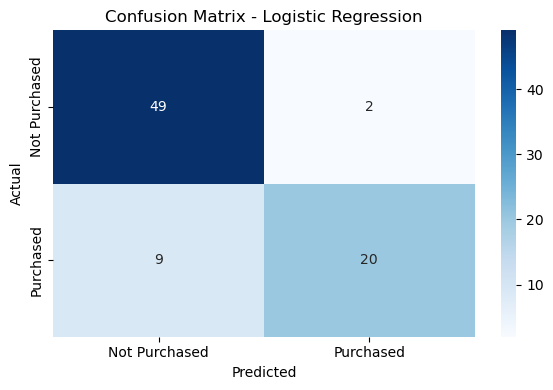

Confusion Matrix Plot saved!


In [40]:
# STEP 9: Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Purchased', 'Purchased'],
            yticklabels=['Not Purchased', 'Purchased'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('exp5_confusion_matrix.png')
plt.show()
print("Confusion Matrix Plot saved!")